# Role Segmentation - An Exploration of Unsupervised Machine Learning on Test Cricket Data

In [2]:
#loading libraries and setting environment variables for performance
import os
os.environ["OMP_NUM_THREADS"] = "2"
from joblib import load
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

Let's first load our data and organise it into a dataframe for clustering. This preprocessed data is from [cricsheet.org](https://cricsheet.org), and contains selected test matches since 2001 (mainly excluding tests from early 2000s and all tests including Afghanistan National Team). 

In [ ]:
#loading pre-processed data
player_data = load('C:\\Users\\olive\\OneDrive\\Documents\\Sports Related Coding Practice\\Cricket\\tests_player_data.joblib')
player_dict = player_data["player_dict"]
batter_summaries = player_data["batter_summaries"]
bowler_summaries = player_data["bowler_summaries"]

In [268]:
#creating dataframe for clustering
df_rows = []
min_games = 20
for player, info in player_dict.items():
    if info["Matches"] >= min_games:
        batting_stats = info.get("Batting Stats", {})
        bowling_stats = info.get("Bowling Stats", {})
        bat_ave = batting_stats.get("Average", 0)
        bat_inn = batting_stats.get("Innings", 0)
        bat_NOs = batting_stats.get("NOs", 0)
        NO_ratio = round(bat_NOs / bat_inn if bat_inn > 0 else 0 ,2)
        bowl_ave  = bowling_stats.get("Average", math.inf)
        if bowl_ave == "-":
            bowl_ave = math.inf
        wickets_pg = float(round(bowling_stats.get("Wickets", 0) / info["Matches"],2))
        runs_pi = float(round(batting_stats.get("Runs", 0) / bat_inn,2))
        df_rows.append({"Player": player, "Matches": info["Matches"],
                        "Batting Average": bat_ave, "Bowling Average": bowl_ave, "Wickets Per Game": wickets_pg, "Runs Per Innings": runs_pi, "NO Ratio": NO_ratio})
df = pd.DataFrame(df_rows)
df.sort_values("Matches", ascending = False)

,Player,Matches,Batting Average,Bowling Average,Wickets Per Game,Runs Per Innings,NO Ratio
101,JM Anderson,182,8.66,26.37,3.75,5.14,0.41
97,SCJ Broad,167,18.04,27.68,3.62,15.07,0.16
91,JE Root,163,51.07,48.15,0.45,46.79,0.08
89,AN Cook,161,45.35,7.00,0.01,42.86,0.05
9,NM Lyon,141,12.60,30.12,4.03,9.28,0.26
...,...,...,...,...,...,...,...
122,L Ngidi,20,4.85,23.38,2.90,3.23,0.33
21,PSP Handscomb,20,37.21,inf,0.00,30.83,0.17
135,KD Karthik,20,26.15,inf,0.00,25.38,0.03
243,Inzamam-ul-Haq,20,39.34,inf,0.00,34.97,0.11


### Metrics
- Batting Average - ubiquitous metric for batting ability, can be slightly misrepresentative of player role due to not outs
- Runs per Innings - potentially better reflective of player's batting role in team, less sensitive to not-outs inflating average of lower order batsmen
- Bowling Average - ubiquitous metric for bowling ability, but has issues with infrequent/non-bowlers where average can be very high / indeterminant (if wickets = 0)
- Wickets per Game - reflects bowler's role in team, doesn't have the indeterminant value for bowlers with 0 wickets

Let's see if we can complete an intuitive transformation on bowling average to remove this indeterminant value issue when wickets = 0.

In [267]:
df["Bowling Average Transformed"] = round(1.1**(-df["Bowling Average"]),2)
df.sort_values("Bowling Average Transformed", ascending = False)

,Player,Matches,Batting Average,Bowling Average,Wickets Per Game,Runs Per Innings,NO Ratio,Bowling Average Transformed
194,MV Boucher,76,28.97,6.00,0.01,26.36,0.09,0.56
89,AN Cook,161,45.35,7.00,0.01,42.86,0.05,0.51
43,LRPL Taylor,109,45.49,16.00,0.03,39.98,0.12,0.22
138,JJ Bumrah,52,6.57,19.69,4.52,4.52,0.31,0.15
24,Babar Azam,61,42.39,21.00,0.03,38.98,0.08,0.14
...,...,...,...,...,...,...,...,...
102,DJ Malan,22,27.54,65.50,0.09,27.54,0.00,0.00
99,G Gambhir,51,41.94,inf,0.00,41.02,0.02,0.00
95,JM Bairstow,100,36.40,inf,0.00,33.94,0.07,0.00
92,GS Ballance,24,40.32,inf,0.00,37.57,0.07,0.00


This demonstrates how bowling average is also more sensitive to outliers than batting average. The top 3 bowlers by this metric are Mark Boucher, Alastair Cook and Ross Taylor, all who are specialist batsmen (and a keeper in the case of Boucher). Therefore the wickets/game metric is going to be a better representation of bowling role and ability, which is our primary focus.

Let's check out the difference between the two batting metrics to identify which is more appropriate.

In [6]:
df["Bat Metric Delta"] = df["Batting Average"] - df["Runs Per Innings"]
df.sort_values("Bat Metric Delta", ascending = False)[["Player","Matches","Batting Average","Runs Per Innings","NO Ratio","Bat Metric Delta"]]

,Player,Matches,Batting Average,Runs Per Innings,NO Ratio,Bat Metric Delta
4,AC Voges,20,61.88,47.90,0.23,13.98
230,WPUJC Vaas,25,35.31,23.54,0.33,11.77
186,S Chanderpaul,76,57.10,45.42,0.20,11.68
197,SM Pollock,27,34.58,24.36,0.30,10.22
236,VVS Laxman,76,51.53,41.95,0.19,9.58
...,...,...,...,...,...,...
185,RR Sarwan,35,41.93,41.93,0.00,0.00
245,Salman Butt,27,31.13,31.13,0.00,0.00
187,DJ Bravo,33,31.98,31.98,0.00,0.00
148,MA Agarwal,21,41.33,41.33,0.00,0.00


Notice certain players averages inflated by a high ratio of not outs, usually occurring over a small sample size (20-30 games). Runs per innings should be a more appropriate metric, representative of both batting ability and role similarly to the wickets per game metric.

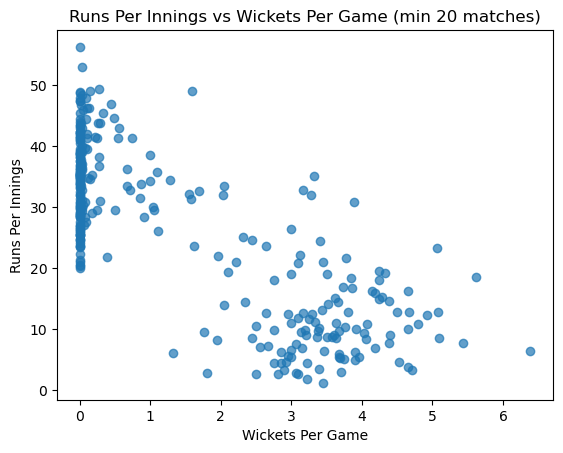

In [14]:
#initial plot of batting average vs wickets per game
plt.scatter(df["Wickets Per Game"], df["Runs Per Innings"], alpha=0.7)
plt.xlabel('Wickets Per Game')
plt.ylabel('Runs Per Innings')
plt.title(f'Runs Per Innings vs Wickets Per Game (min {min_games} matches)')
plt.show()

We can see two main clusters (i.e batsmen and bowlers) with some noise in between (all-rounder variants). Intuitively 2 clusters would work fine, but will oversimplify and exclude the function of all-rounders. 3 clusters could also work to take this into account. Ignoring this obvious 2 cluster case, let's see if K > 2 configuration could be optimal to differentiate the function/role of players in their teams.

In [271]:
#importing libraries for clustering and scaling
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [272]:
#scaling data for clustering
scaler = StandardScaler()
features = ["Wickets Per Game", "Runs Per Innings"]
X = df[features].to_numpy()
X_scaled = scaler.fit_transform(X)

## K-Means Clustering

K-Means clustering works by partitioning data into k distinct, non-overlapping clusters and minimising variance within each cluster. K centroids are initialised, data points are assigned to each centroid by Euclidean distance, and the centroids are recalculated based on this assignment. This process is repeated until stability is achieved (points stop changing cluster). As a distance-based algorithm, it assumes clusters are convex and spherical and is sensitive to initial centroid choice.

Let's run some tests to evaluate the optimal K (number of clusters).

In [269]:
#determining optimal number of clusters using elbow method and silhouette scores
inertias = [] #aka within-cluster sum of squares
silhouettes = []
K = range(2, 15)

for k in K:
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))


The elbow method is a visual technique used to estimate the optimal number of clusters (K) in K-Means clustering, by calculately the within-cluster sum of squares (WCSS). The "elbow" point in the graph represents the best trade-off between model complexity and performance, where decreasing number of clusters (moving left) will significantly increasing the variation within clusters while increasing the number of clusters (moving right) will increase complexity without huge performance benefits.

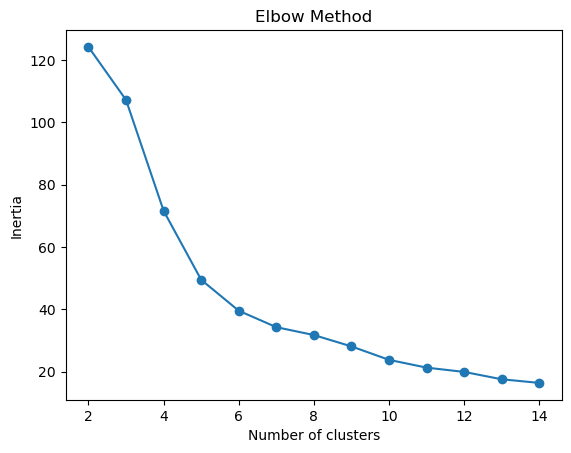

In [22]:
#plotting elbow method results
plt.plot(K, inertias, 'o-')
plt.title("Elbow Method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

We can clearly see the elbow at K = 5. 

The silhouette score method measures how similar a data point is to its own cluster compared to other clusters, ranging from +1 (close to its own cluster, far from neighbouring clusters) to -1 (far from own cluster and close to others, maybe assigned to wrong cluster). By calculating the average silhouette score for each K, the configuration with the highest score should indicate the optimal number of clusters.

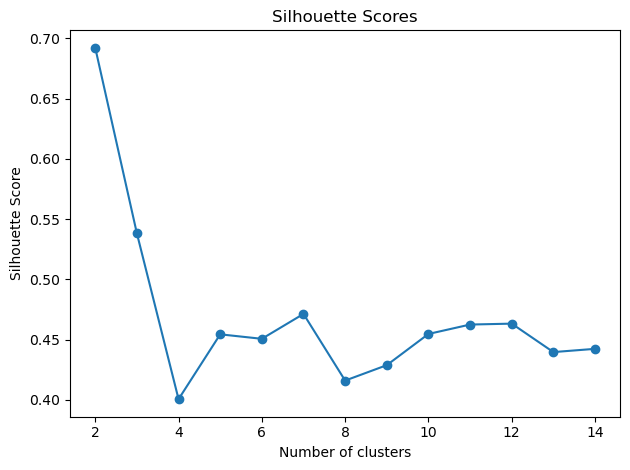

In [23]:
#plotting silhouette scores
plt.plot(K, silhouettes, 'o-')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")
plt.tight_layout()
plt.show()


This graph suggests 2, 7 or 12 clusters - notice the local maxima at these K. Obviously K = 2 is the easy clustering but oversimplifies, not taking into account All-Rounders at all. K = 12 may be overcomplicated, but we could potentially explore going forward.

Taking both methods into account, lets try K-Means first for K = 5 and K = 7.

                Runs Per Innings  Wickets Per Game
KMeans Cluster                                    
0                          32.09              1.20
1                           8.64              3.59
2                          28.65              0.03
3                          41.24              0.09
4                          22.10              3.22


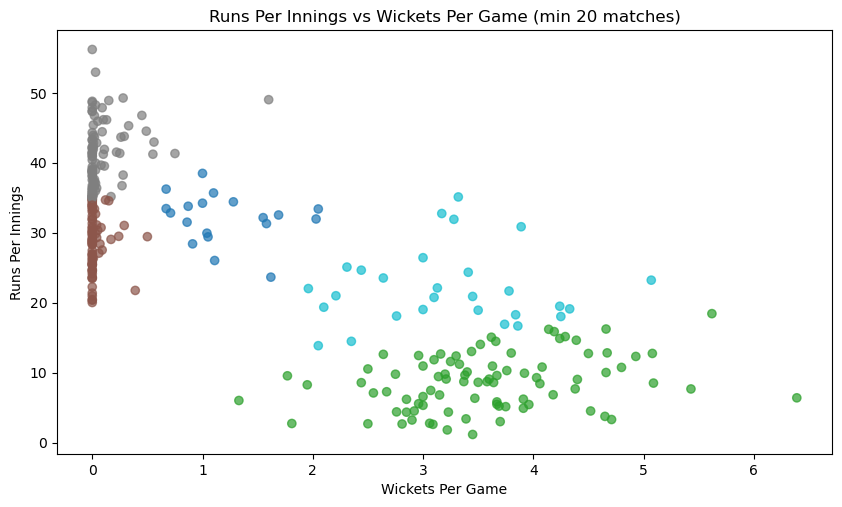

In [273]:
K = 5
kmeans = KMeans(n_clusters=K, random_state=0, n_init = "auto").fit(X_scaled)
df[f"KMeans Cluster"] = kmeans.labels_
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(10,5.5))
plt.scatter(df['Wickets Per Game'], df['Runs Per Innings'], c=df[f'KMeans Cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('Wickets Per Game')
plt.ylabel('Runs Per Innings')
plt.title(f'Runs Per Innings vs Wickets Per Game (min {min_games} matches)')
print(df.groupby([f"KMeans Cluster"])[["Runs Per Innings","Wickets Per Game"]].mean().round(2))

Groupings:
- Batsmen x 2 (by ability)
- All-Rounders x 2 (by dominant role - batting or bowling)
- Bowlers x 1

                Runs Per Innings  Wickets Per Game
KMeans Cluster                                    
0                          32.09              1.20
1                           5.34              2.94
2                          28.65              0.03
3                          41.24              0.09
4                          24.14              2.97
5                          12.03              4.62
6                          11.46              3.40


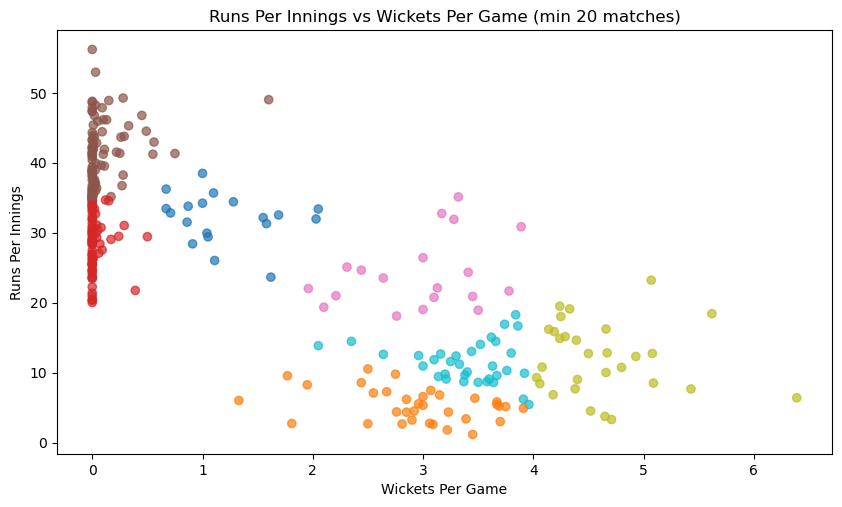

In [274]:
K = 7
kmeans = KMeans(n_clusters=K, random_state=0, n_init = "auto").fit(X_scaled)
df[f"KMeans Cluster"] = kmeans.labels_
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.figure(figsize=(10,5.5))
plt.scatter(df['Wickets Per Game'], df['Runs Per Innings'], c=df[f'KMeans Cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('Wickets Per Game')
plt.ylabel('Runs Per Innings')
plt.title(f'Runs Per Innings vs Wickets Per Game (min {min_games} matches)')
print(df.groupby([f"KMeans Cluster"])[["Runs Per Innings","Wickets Per Game"]].mean().round(2))

Groupings:
- Batsmen x 2 (by ability)
- All-Rounders x 2 (by dominant role)
- Bowlers x 3 (by ability/impact)

Adding two extra clusters has effectively split the single bowling cluster from the K = 5 configuration into 3. This is done roughly by overall impact (differently to how the batsmen are just split by their batting ability), particularly noticably in the diagonal divide between the orange and blue clusters. This is primarily due to the nature of cricket - everyone bats, while only some people bowl regularly - so the variation in batting ability in the bowlers is more apparent in the data than vice versa.

Let's name these 7 clusters.

In [275]:
#naming clusters in K = 7 configuration
kmeans_cluster_names = {
    0: "All-Rounder - Batting",
    1: "Bowler - Low Impact",
    2: "Batsman - Low Impact",
    3: "Batsman - High Impact",
    4: "All-Rounder - Bowling",
    5: "Bowler - High Impact",
    6: "Bowler - Medium Impact",
}

df['KMeans Cluster Name'] = df['KMeans Cluster'].map(kmeans_cluster_names)

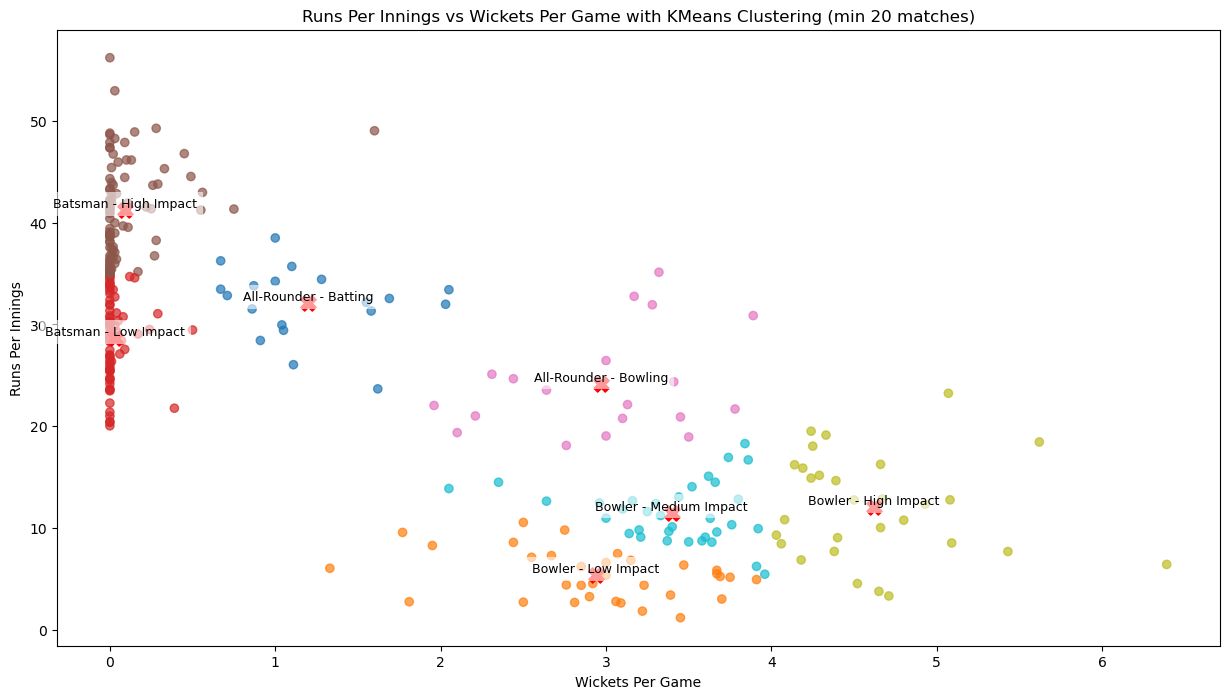

In [276]:
plt.figure(figsize=(15, 8))
plt.scatter(df['Wickets Per Game'], df['Runs Per Innings'], c=df['KMeans Cluster'], cmap='tab10', alpha=0.7)

# plot centroids and annotate with cluster names
plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], c='red', marker='X', s=120, label='Centroids')
for i, (cx, cy) in enumerate(cluster_centers):
    name = kmeans_cluster_names.get(i, str(i))
    plt.text(cx, cy, name, fontsize=9, ha='center', va='bottom',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.xlabel('Wickets Per Game')
plt.ylabel('Runs Per Innings')
plt.title(f'Runs Per Innings vs Wickets Per Game with KMeans Clustering (min {min_games} matches)')
plt.show()

#### Conclusion - KMeans Clustering 

Strengths:
- Generally accurate in role classification and sub-classification

Weaknesses:
- Doesn't differentiate between bowling ability of primary batsmen - grouping is by runs per innings only, not between "Doesn't bowl, part-time bowler" etc
- Somewhat inconsistent in sub-classification within main groups - just ability for batsmen but combined impact for bowlers & all-rounders
- Edge case inaccuracy e.g. Jacques Kallis is elite batsman


## Agglomerative Clustering

Agglomerative clustering is a "bottom-up" hierarchical method. Each data point starts in its own cluster and the closest pair based on similarity metrics and linkage criteria are merged into a new cluster. We use the Ward linkage crieteria, which minimises total within-cluster variance. This process is repeated iteratively until all points belong to one cluster (or a threshold is met). This process is demonstrated visually in the dendogram below.

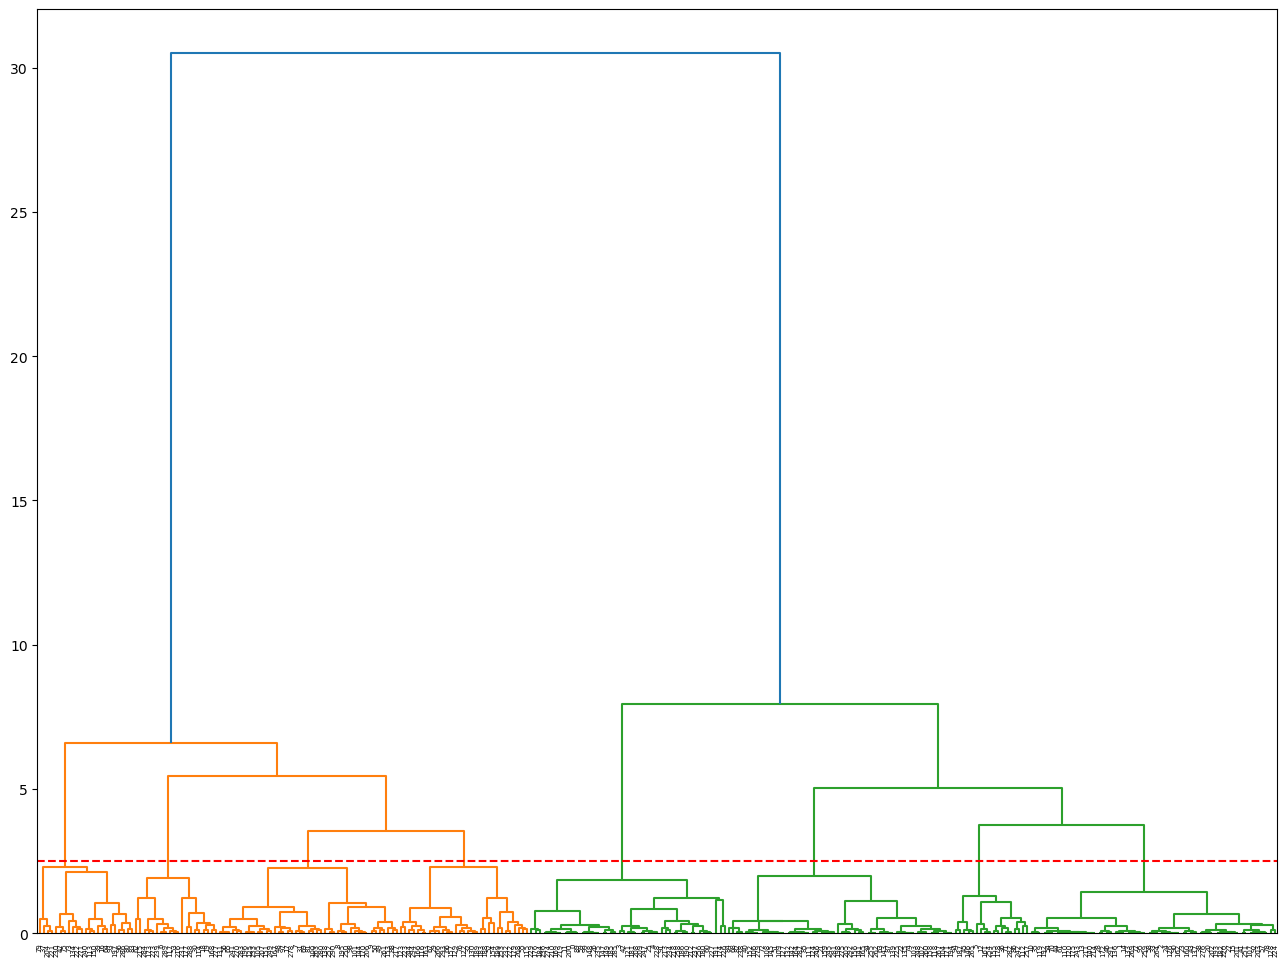

In [99]:
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch

# Plot dendrogram
mergings = sch.linkage(X_scaled, method='ward')
plt.figure(figsize = (16,12))
sch.dendrogram(mergings)
plt.axhline(2.5, linestyle='--', c='red')
plt.show()


Similarly to the KMeans method, we must decide on the number of clusters. This can be done visually or with the aid of the silhouette score method.

Visually, anywhere between K = 2 and K = 8 seems like a valid number of clusters. This distinction is indicated by the dotted red line plotted, below which rapid declustering occurs. Observe this in the plots below, plotting the clusters up to K = 16. New clustering become increasingly insignificant as K increases beyond 8.

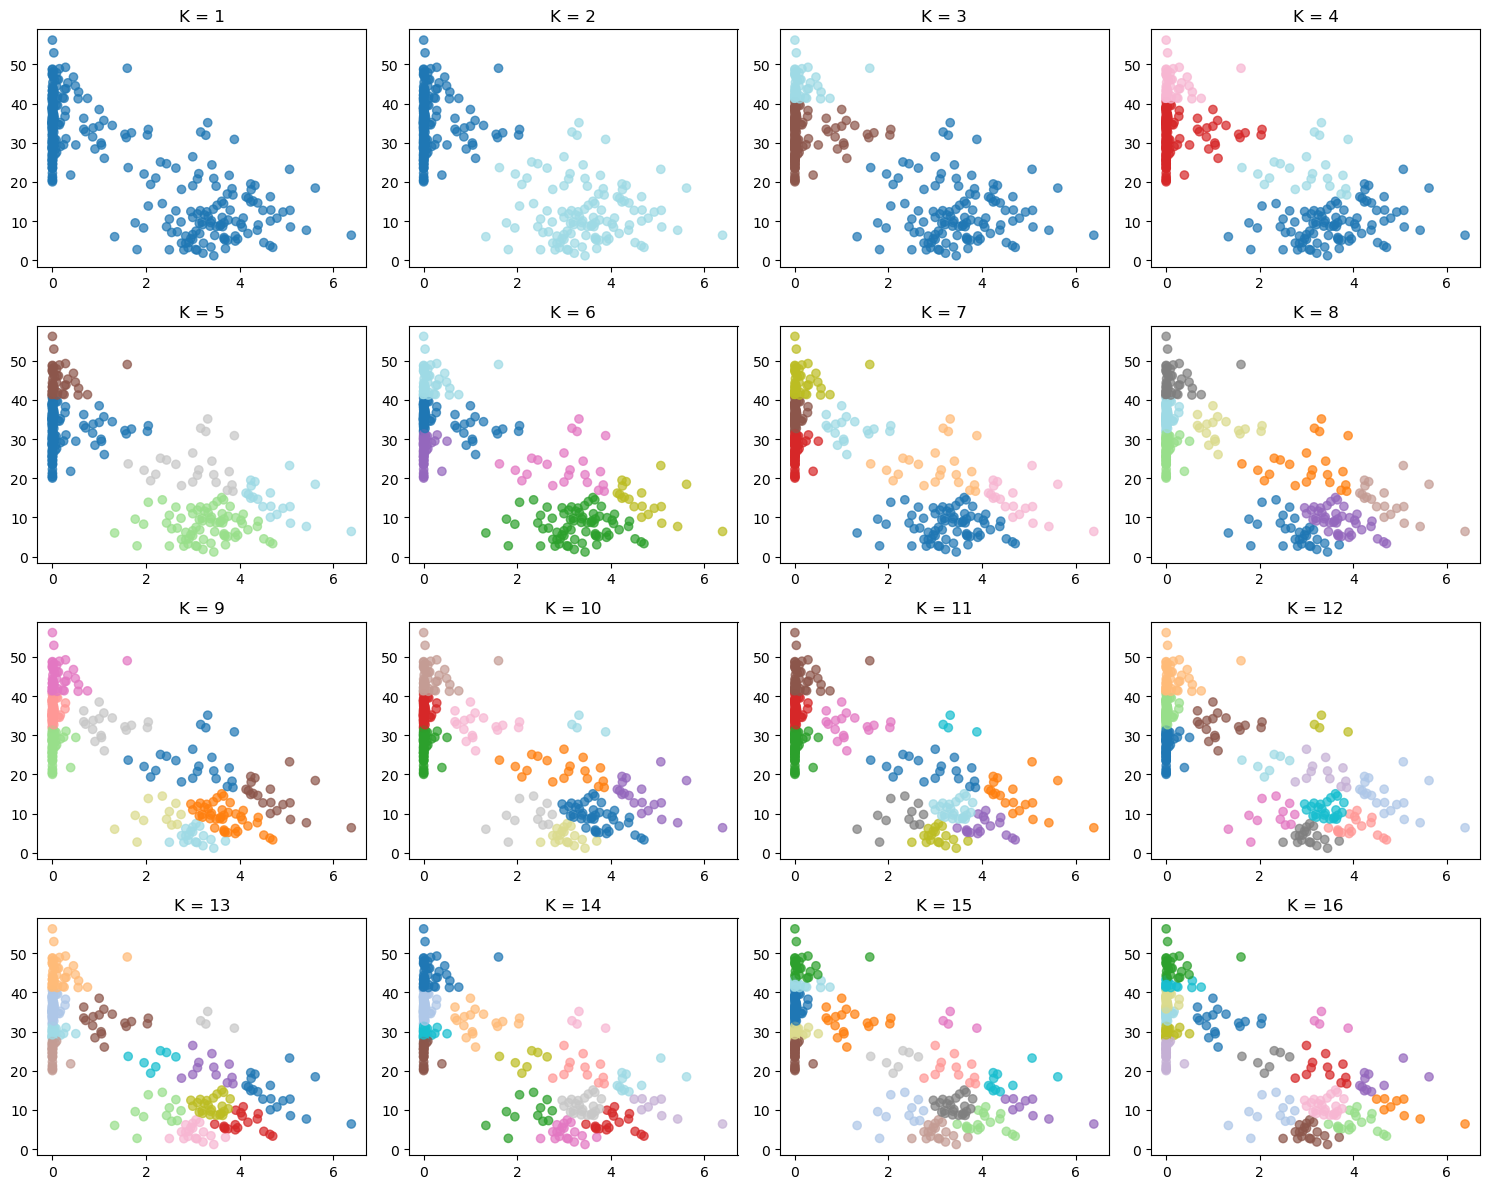

In [ ]:
fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(15, 12))
axs.flatten()
for k in range(1,17):
    agg_cluster_labels = AgglomerativeClustering(n_clusters = k, linkage = "ward").fit(X_scaled)
    df["Agg Cluster"] = agg_cluster_labels.labels_
    agg_cluster_centers = df.groupby(["Agg Cluster"])[features].mean().round(2)
    agg_cluster_centers = agg_cluster_centers.to_numpy()
    axs.flat[k-1].scatter(df["Wickets Per Game"], df["Runs Per Innings"], c=df["Agg Cluster"], cmap='tab20', alpha=0.7)
    axs.flat[k-1].set_title(f"K = {k}")
plt.tight_layout()
plt.show()

Now let's use the silhouette score method to quantitatively evaluate optimal cluster configurations.

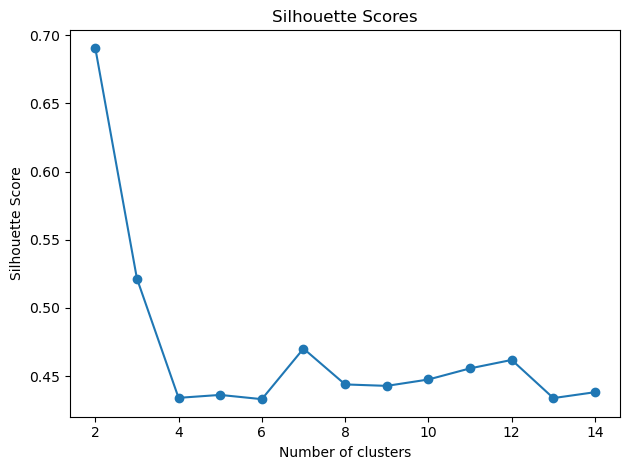

In [79]:
silhouettes = []
K = range(2, 15)

for k in K:
    ac = AgglomerativeClustering(n_clusters=k, linkage='ward').fit(X_scaled)
    silhouettes.append(silhouette_score(X_scaled, ac.labels_))

plt.plot(K, silhouettes, 'o-')
plt.title("Silhouette Scores")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

Evidently, K = 7 is the optimal number of clusters for K > 2. This makes sense, as one of the optimal KMeans cluster configurations was also K = 7, and is similarly based on a distance metric.

             Wickets Per Game  Runs Per Innings
Agg Cluster                                    
0                        3.28              7.88
1                        3.02             23.23
2                        0.04             26.98
3                        0.03             36.11
4                        4.75             14.27
5                        0.15             44.78
6                        1.18             32.56


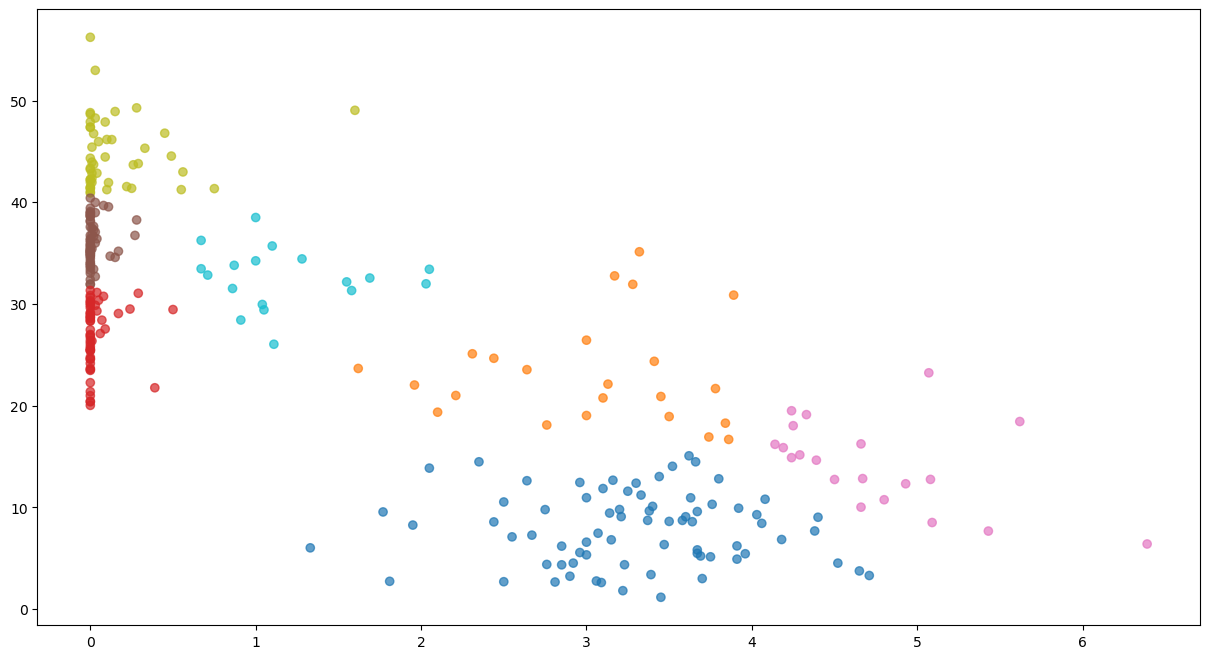

In [109]:
k = 7
agg_cluster_labels = AgglomerativeClustering(n_clusters = k, linkage = "ward").fit(X_scaled)
df["Agg Cluster"] = agg_cluster_labels.labels_
agg_cluster_centers = df.groupby(["Agg Cluster"])[features].mean().round(2)
print(agg_cluster_centers)
agg_cluster_centers = agg_cluster_centers.to_numpy()
plt.figure(figsize=(15,8))
plt.scatter(df["Wickets Per Game"], df["Runs Per Innings"], c=df["Agg Cluster"], cmap='tab10', alpha=0.7)
plt.show()

Groupings:
- Batsmen x 3 (by ability)
- All-Rounders x 2 (by dominant role)
- Bowlers x 2 (by ability/impact)

This differs from the K = 7 configuration with the KMeans algorithm, which had 3 specialist bowler clusters and only 2 specialist batsmen clusters. This creates greater variance within the low-medium impact bowler cluster. Testing K = 8 would seem to potentially reduce this, even if its not reflected by an optimal silhouette score.

             Wickets Per Game  Runs Per Innings
Agg Cluster                                    
0                        2.73              6.12
1                        3.02             23.23
2                        0.04             26.98
3                        3.68              9.15
4                        4.75             14.27
5                        0.15             44.78
6                        1.18             32.56
7                        0.03             36.11


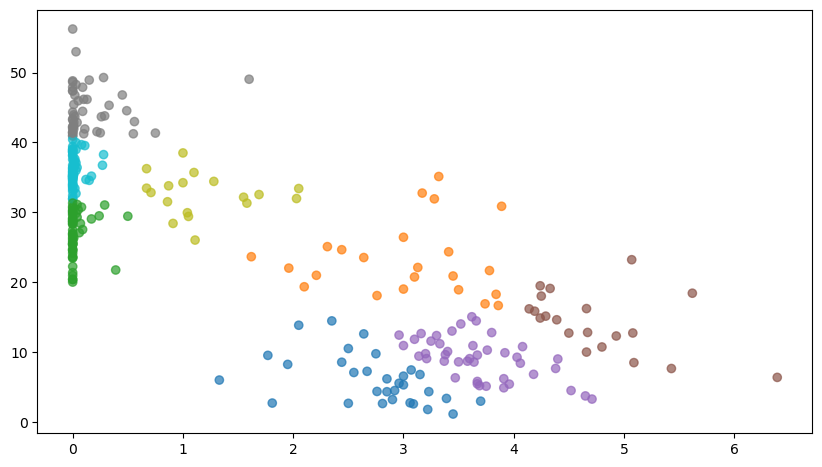

In [119]:
k = 8
agg_cluster_labels = AgglomerativeClustering(n_clusters = k, linkage = "ward").fit(X_scaled)
df["Agg Cluster"] = agg_cluster_labels.labels_
agg_cluster_centers = df.groupby(["Agg Cluster"])[features].mean().round(2)
print(agg_cluster_centers)
agg_cluster_centers = agg_cluster_centers.to_numpy()
plt.figure(figsize=(10,5.5))
plt.scatter(df["Wickets Per Game"], df["Runs Per Innings"], c=df["Agg Cluster"], cmap='tab10', alpha=0.7)
plt.show()

Let's name these 8 clusters.

In [114]:
agg_cluster_names = {
    0: "Bowler - Low Impact",
    1: "All-Rounder - Bowling",
    2: "Batsman - Low Impact",
    3: "Bowler - Medium Impact",
    4: "Bowler - High Impact",
    5: "Batsman - High Impact",
    6: "All-Rounder - Batting",
    7: "Batsman - Medium Impact"
    }
df['Agg Cluster Name'] = df['Agg Cluster'].map(agg_cluster_names)

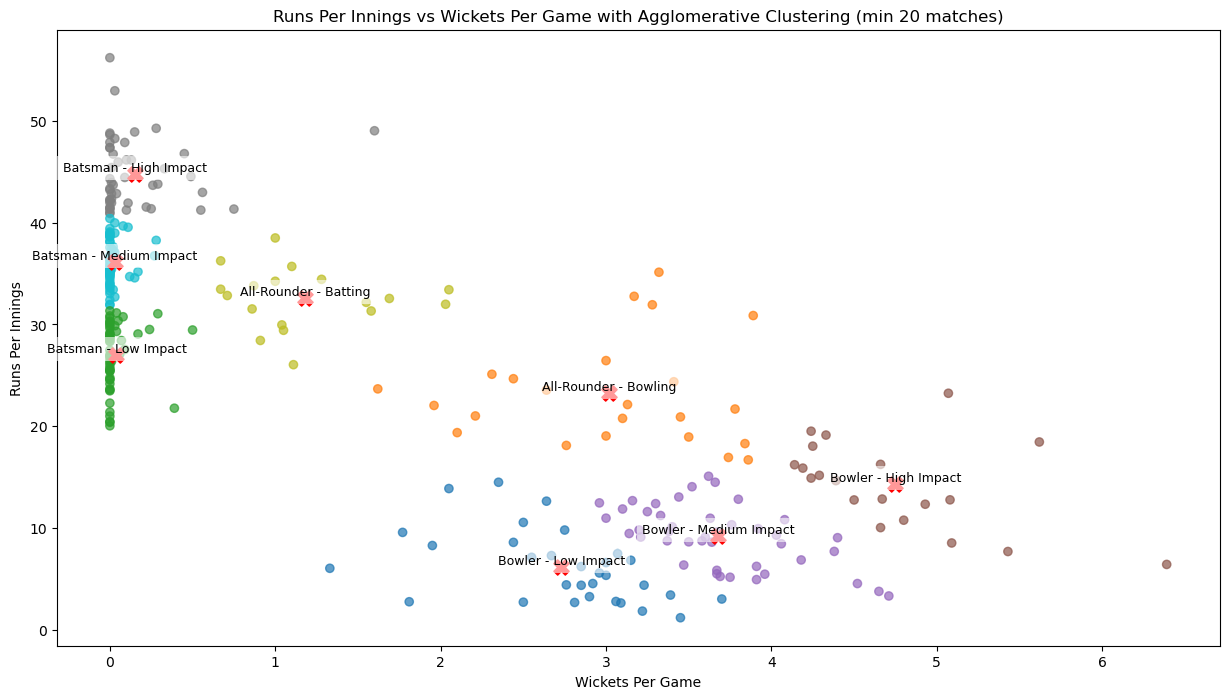

In [116]:
# plot centroids and annotate with cluster names
plt.figure(figsize=(15,8))
plt.scatter(df["Wickets Per Game"], df["Runs Per Innings"], c=df["Agg Cluster"], cmap='tab10', alpha=0.7)

for i, (cx, cy) in enumerate(agg_cluster_centers):
    plt.scatter(cx, cy, c='red', marker='X', s=120)
    name = agg_cluster_names.get(i, str(i))
    plt.text(cx, cy, name, fontsize=9, ha='center', va='bottom',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.xlabel('Wickets Per Game')
plt.ylabel('Runs Per Innings')
plt.title(f'Runs Per Innings vs Wickets Per Game with Agglomerative Clustering (min {min_games} matches)')
plt.show()

Let's compare the plots for both KMeans and Agglomerative clustering.

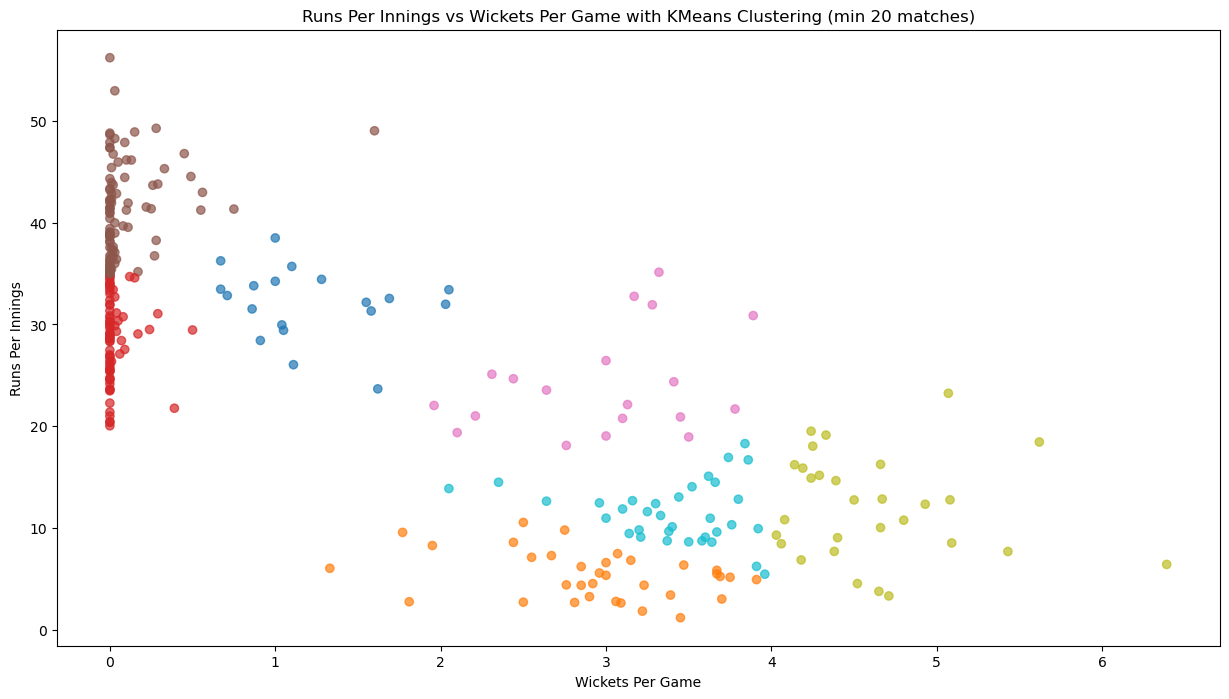

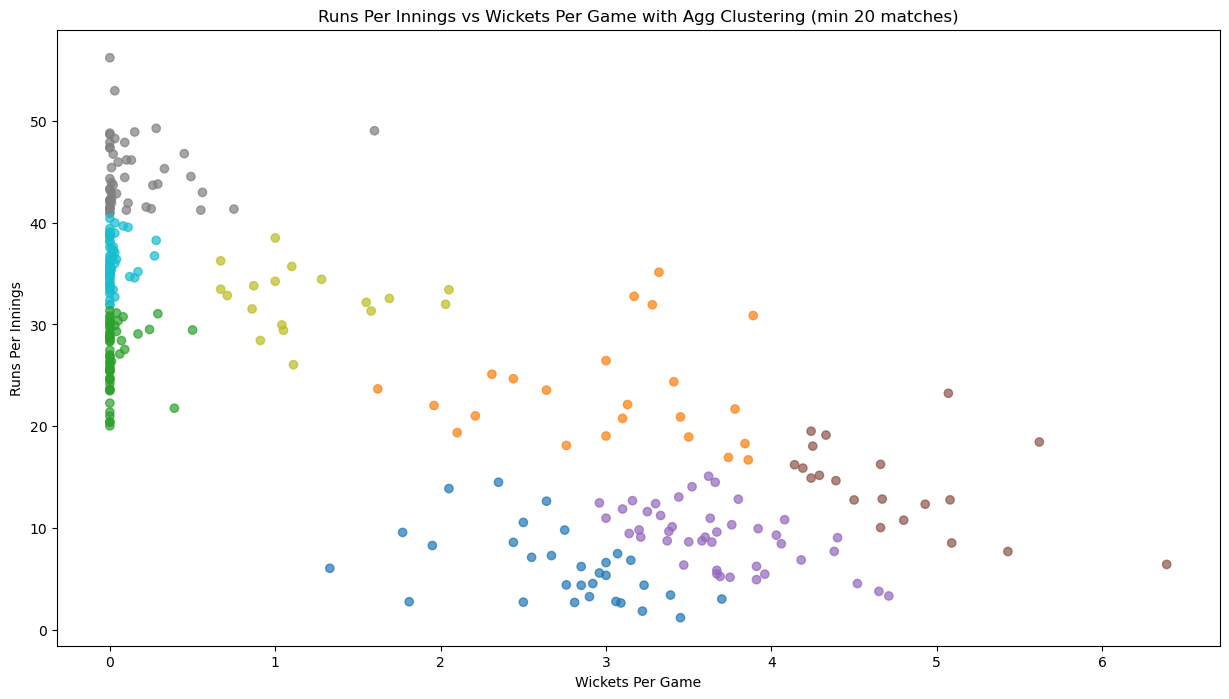

In [133]:
for method in ["KMeans","Agg"]:
    plt.figure(figsize=(15,8))
    plt.scatter(df["Wickets Per Game"], df["Runs Per Innings"], c=df[f"{method} Cluster"], cmap='tab10', alpha=0.7)

    plt.xlabel('Wickets Per Game')
    plt.ylabel('Runs Per Innings')
    plt.title(f'Runs Per Innings vs Wickets Per Game with {method} Clustering (min {min_games} matches)')
    plt.show()

Aside from the obvious difference in batsmen clustering, notice certain edge case differences between the two, specifically around the all-rounders and bowlers. This is most notable in the cluster shape difference for the Medium Impact Bowler cluster. 

### Conclusion - Agglomerative Clustering

Strengths:
- Generally accurate in role classification and sub-classification

Weaknesses:
- Just like KMeans, it does not take into account bowling ability of primary batsmen 
- Edge case inaccuracy e.g. Jacques Kallis is elite batsman

Compared to KMeans:
- Different shape of "Bowler - Medium Impact" cluster
- For K = 7 case, there is different segmentations (3 bowling clusters for KMeans, 3 batting clusters for Agglom.)
- Remaining variation mainly in edge cases
- Otherwise similar behaviour - expected as it is also a distance-based algorithm
- Differences likely due to Kmeans senstivity to initial centroids used in algorithm

## Gaussian Mixture Models

Gaussian Mixture Model (GMM) clustering is an algorithm that models data as a mixture of multiple Gaussian (normal) distributions. Unlike the previous methods, it involves "soft clustering" - instead of assigning each point to a cluster, the probability of a data point belonging to each cluster is calculated. Typically, an Expectation-Maximisation algorithm is used to fit the model, starting with a certain configuration of K clusters, calculating probability (expectation), updating parameters (based on max. likelihood) and repeating until convergence. This probabilistic method allows for flexible, non-spherical cluster shapes, which may be more appropriate to this data. 

In [155]:
from sklearn.mixture import GaussianMixture

We can use the Bayesian Information Criterion (BIC) to identify the optimal number of clusters. A clear minimum or an "elbow" pattern will indicate where the ideal number of clusters lies.

k = 1, BIC = 1415.13
k = 2, BIC = 455.92
k = 3, BIC = 358.96
k = 4, BIC = 158.98
k = 5, BIC = 183.61
k = 6, BIC = 167.59
k = 7, BIC = 183.61
k = 8, BIC = 198.17


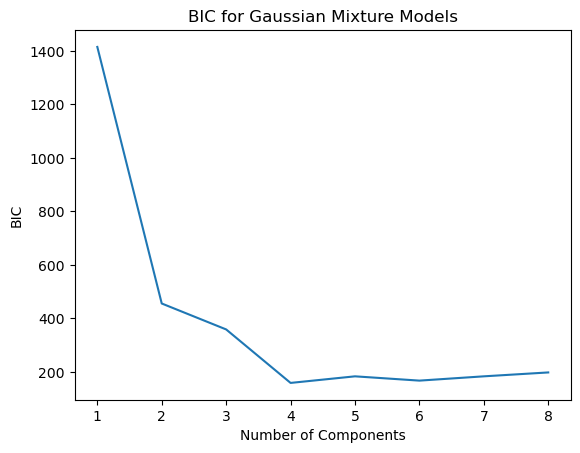

In [183]:
k = range(1,9)

bics = []

for n in k:
    gmm = GaussianMixture(n_components=n, random_state=42)
    labels = gmm.fit_predict(X_scaled)
    bics.append(gmm.bic(X_scaled))
    print(f"k = {n}, BIC = {round(bics[-1],2)}")

plt.figure()
plt.plot(k, bics)
plt.xlabel("Number of Components")
plt.ylabel("BIC")
plt.title("BIC for Gaussian Mixture Models")
plt.show()

We can see visually (and numerically) that the ideal configuration according to this method is with 4 clusters. The 6 cluster configuration could also be worth exploring. Let's plot these.

             Runs Per Innings  Wickets Per Game
GMM Cluster                                    
0                       38.64              0.09
1                        8.87              3.48
2                       28.08              2.29
3                       33.45              0.00


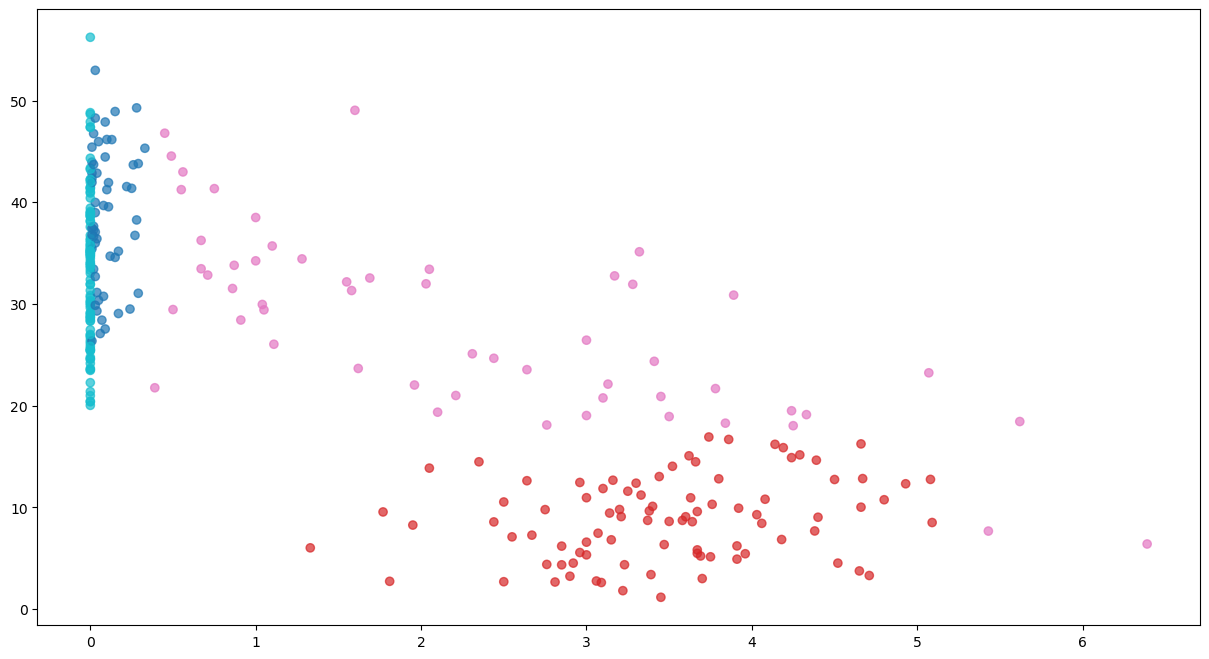

In [184]:
k = 4
gmm = GaussianMixture(n_components=k, random_state=42)
labels = gmm.fit_predict(X_scaled)
df["GMM Cluster"] = labels
gmm_cluster_centers = df.groupby("GMM Cluster")[["Runs Per Innings","Wickets Per Game"]].mean().round(2)
print(gmm_cluster_centers)
gmm_cluster_centers = gmm_cluster_centers.to_numpy()

plt.figure(figsize=(15,8))
plt.scatter(df["Wickets Per Game"], df["Runs Per Innings"], c=df["GMM Cluster"], cmap='tab10', alpha=0.7)
plt.show()

Immediately, the large cluster of all-rounders and some elite bowlers is concerningly broad. Let's see if the "second most optimal" (by BIC) k = 6 resolves this.

             Runs Per Innings  Wickets Per Game
GMM Cluster                                    
0                       37.97              0.02
1                       16.08              4.22
2                        7.60              3.27
3                       39.36              0.17
4                       32.10              1.54
5                       33.45              0.00


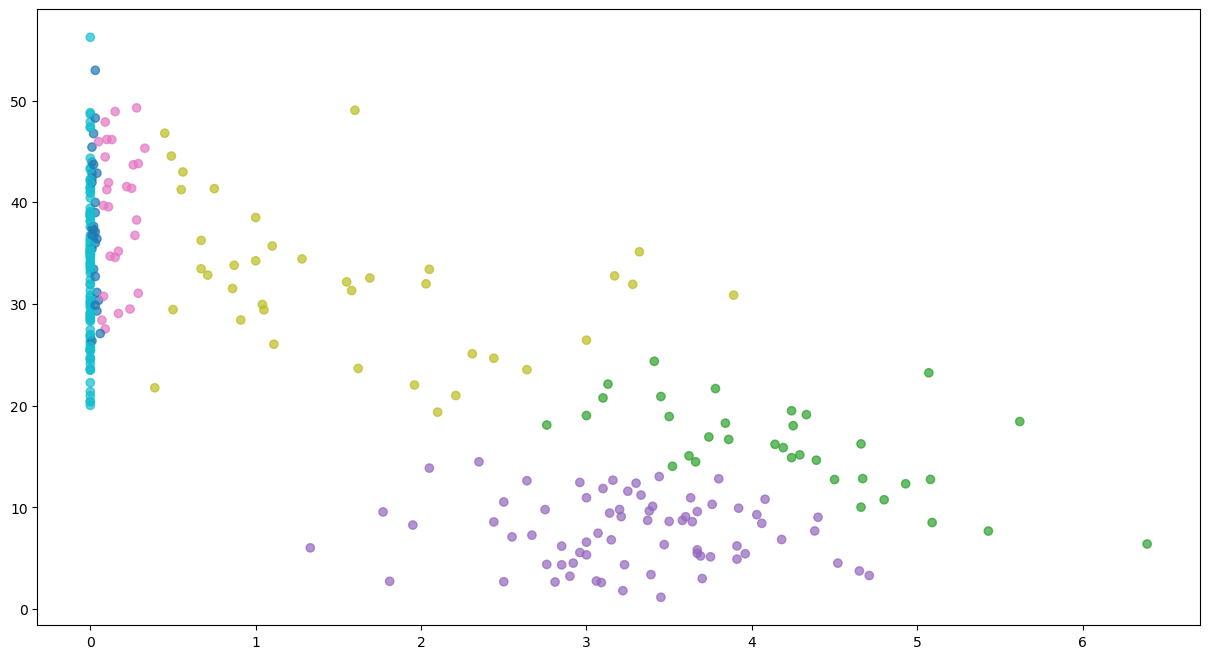

In [191]:
k = 6
gmm = GaussianMixture(n_components=k, random_state=42)
labels = gmm.fit_predict(X_scaled)
df["GMM Cluster"] = labels
gmm_cluster_centers = df.groupby("GMM Cluster")[["Runs Per Innings","Wickets Per Game"]].mean().round(2)
print(gmm_cluster_centers)
gmm_cluster_centers = gmm_cluster_centers.to_numpy()

plt.figure(figsize=(15,8))
plt.scatter(df["Wickets Per Game"], df["Runs Per Innings"], c=df["GMM Cluster"], cmap='tab10', alpha=0.7)
plt.show()

As desired, this divides the big all-rounders cluster (and also adds another specialist batsmen cluster).

Groupings:

- Batsmen x 3 (by bowling impact)
- Batting All-Rounders
- Bowling All-Rounders + Elite Bowlers
- Bowlers (non-elite)

Immediately, we can see a clear difference in the way the algorithm clusters batsmen compared to the previous two distance-based methods. The division is by the batsmen's bowling ability/function. By considering non-spherical clustering possibilities, this GMM method has seen this nuance in the data, largely ignored by the other algorithms.

All-Rounders are segmented differently too, with one larger cluster with batting all-rounders and general all-rounders, and another cluster with bowling all-rounders as well as elite bowlers. In fact, this "bowling all-rounder" cluster could be more considered a bowler cluster, distinct based on overall impact to the other bowling cluster, similar to the bowler segmentation by the previous methods.

Let's label this k = 6 case.

In [192]:
gmm_cluster_names = {
    0: "Batsman - Occasional Bowler",
    1: "Bowler - High Impact",
    2: "Bowler - Low Impact",
    3: "Batsman - Part-time Bowler",
    4: "All-Rounder - Batting",
    5: "Batsman - Never Bowls" }
df['GMM Cluster Name'] = df['GMM Cluster'].map(gmm_cluster_names)

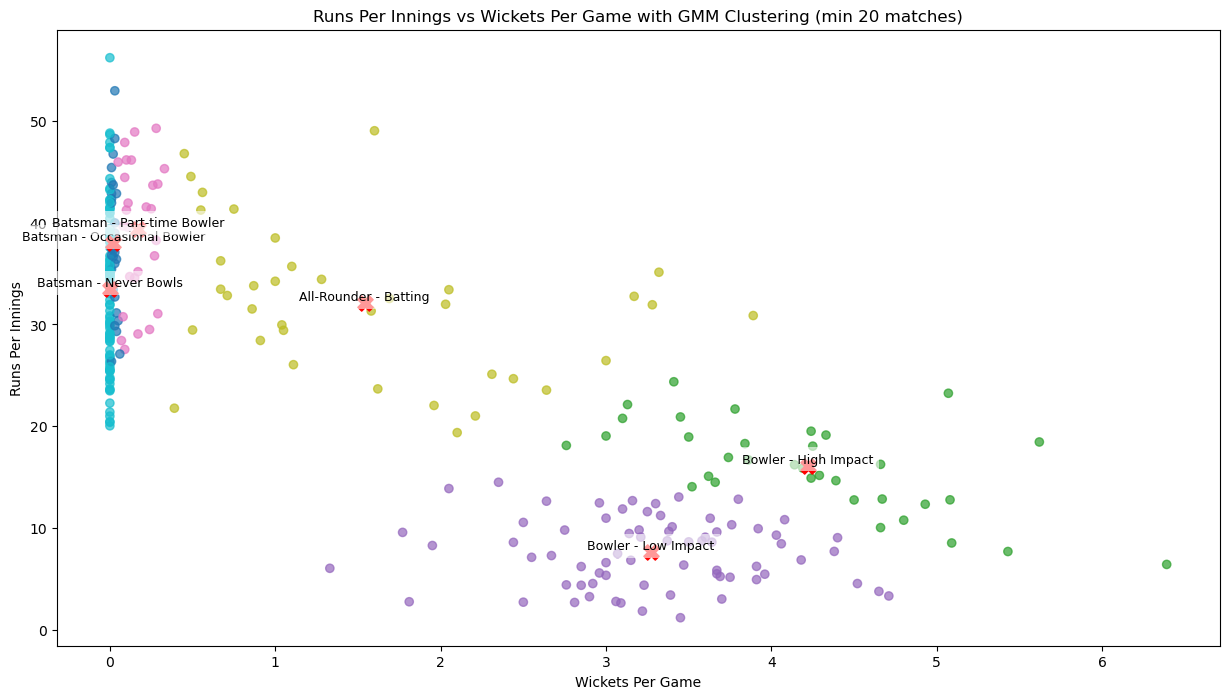

In [ ]:
plt.figure(figsize=(15,8))
plt.scatter(df["Wickets Per Game"], df["Runs Per Innings"], c=df["GMM Cluster"], cmap='tab10', alpha=0.7)
for i, (cy, cx) in enumerate(gmm_cluster_centers):
    plt.scatter(cx, cy, c='red', marker='X', s=120)
    name = gmm_cluster_names.get(i, str(i))
    plt.text(cx, cy, name, fontsize=9, ha='center', va='bottom',
             bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

plt.xlabel('Wickets Per Game')
plt.ylabel('Runs Per Innings')
plt.title(f'Runs Per Innings vs Wickets Per Game with GMM Clustering (min {min_games} matches)')
plt.show()

Due to the tall-narrow clusters of the three batting clusters, the labelling isn't as clear in this section of the graph.

Let's compare this batting clustering statistically with the final agglomerative configuration, which also had three divisions but done by batting ability.

In [201]:
print("GMM6 Config:")
for cluster_no, cluster_df in df.groupby(["GMM Cluster"]):
    if "Batsman" in gmm_cluster_names.get(cluster_no[0], ""):
        print(f"{gmm_cluster_names.get(cluster_no[0],"")}:")
        print(cluster_df[["Runs Per Innings","Wickets Per Game"]].agg(["mean","std"]).apply(lambda x: x['mean'].round(2).astype(str) + " ± " + x['std'].round(2).astype(str)).to_string())
        #print(cluster_df.sort_values("Impact Value", ascending=False)["Player"].head().to_string())
        print()
print("------------------------------")
print("Agg8 Config:")
for cluster_no, cluster_df in df.groupby(["Agg Cluster"]):
    if "Batsman" in agg_cluster_names.get(cluster_no[0], ""):
        print(f"{agg_cluster_names.get(cluster_no[0],"")}:")
        print(cluster_df[["Runs Per Innings","Wickets Per Game"]].agg(["mean","std"]).apply(lambda x: x['mean'].round(2).astype(str) + " ± " + x['std'].round(2).astype(str)).to_string())
        #print(cluster_df.sort_values("Impact Value", ascending=False)["Player"].head().to_string())
        print()

GMM6 Config:
Batsman - Occasional Bowler:
Runs Per Innings    37.97 ± 6.51
Wickets Per Game     0.02 ± 0.01

Batsman - Part-time Bowler:
Runs Per Innings    39.36 ± 6.78
Wickets Per Game     0.17 ± 0.09

Batsman - Never Bowls:
Runs Per Innings    33.45 ± 7.42
Wickets Per Game       0.0 ± 0.0

------------------------------
Agg8 Config:
Batsman - Low Impact:
Runs Per Innings    26.98 ± 3.17
Wickets Per Game      0.04 ± 0.1

Batsman - High Impact:
Runs Per Innings    44.78 ± 3.39
Wickets Per Game     0.15 ± 0.28

Batsman - Medium Impact:
Runs Per Innings    36.11 ± 2.18
Wickets Per Game     0.03 ± 0.06



The different segmentation is evident in the standard deviation of each. In the GMM configuration, with division by bowling role/ability, there is less variation in the bowling metric but greater variation in the batting metric. It is the opposite in the agglomerative configuration, which has less variation in the batting metric but more in the bowling metric. 

### Conclusion - GMM Clustering

Strengths:
- Recognises bowling functionality of batsmen - distinguishes the specialist batsmen by their bowling frequency/ability rather than their batting ability
- Some edge case improvements - finally Jacques Kallis is included in an all-rounder cluster rather than a batting one!

Weaknesses:
- Great variation in batting ability with these batsmen clusters - an issue if we want impact to be reflected in the batting segmentation like it is in the other clusters


## Overall

This work so far shows certain strengths and weaknesses of these three clustering techniques within the context of cricket player role segmentation. Most notably, the difference between distance-based methods like KMeans and Agglomerative and distribution-based methods like GMM is evident from the different clusters derived.

Going forward, there may be exploration with further clustering methods, as well as implementation of a Principal Component Analysis phase before clustering.